# Segmentasi Lesi dengan U-Net EfficientNet-B0

Digunakan untuk melatih model segmentasi lesi pada daun anggur menggunakan arsitektur U-Net dengan encoder EfficientNet-B0 pretrained ImageNet.

Input model lesi dibuat dari citra daun yang telah diproses menggunakan model segmentasi daun. Area luar daun dibuat hitam agar model lebih fokus pada area daun dan bercak penyakit.

Tahapan utama dalam notebook ini meliputi preprocessing citra, pembuatan masked image berdasarkan prediksi mask daun, augmentasi data, pelatihan model, evaluasi performa, pemilihan threshold, dan pengujian akhir pada data test.

Model dilatih untuk menghasilkan mask lesi yang kemudian digunakan dalam perhitungan tingkat keparahan penyakit berdasarkan perbandingan luas lesi terhadap luas daun.


## 1. Install dan Import Library

In [3]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.3.1

In [26]:
import json
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import shutil

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

## 2. Mount Drive dan Konfigurasi


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
MYDRIVE = Path('/content/drive/MyDrive')
ROOT = MYDRIVE / 'SkripsiFinal' / 'grape_disease_project'

LESION_DATASET_DIR = ROOT / 'dataset_segmentasi_lesi'
LEAF_DATASET_DIR = ROOT / 'dataset_segmentasi_daun'

LEAF_MODEL_NAME = 'model_segmentasi_daun_efficientnetb0'
LEAF_MODEL_DIR = MYDRIVE / 'SkripsiFinal' / 'models' / LEAF_MODEL_NAME
LEAF_MODEL_PATH = LEAF_MODEL_DIR / f'{LEAF_MODEL_NAME}_best.pth'
LEAF_CONFIG_PATH = LEAF_MODEL_DIR / f'{LEAF_MODEL_NAME}_config.json'

MODEL_NAME = 'model_segmentasi_lesi_efficientnetb0'
MODEL_DIR = MYDRIVE / 'SkripsiFinal' / 'models' / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_best.pth'
LAST_MODEL_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_last.pth'
CONFIG_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_config.json'
CURVE_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_training_curves.png'
THRESHOLD_SWEEP_CSV = MODEL_DIR / f'{MODEL_NAME}_threshold_sweep_val.csv'
TEST_EVAL_CSV = MODEL_DIR / f'{MODEL_NAME}_test_eval.csv'
SEVERITY_EVAL_CSV = MODEL_DIR / f'{MODEL_NAME}_severity_eval.csv'

PREDLEAF_DATASET_DIR = MODEL_DIR / 'dataset_predleaf_bgblack'
PREDLEAF_DATASET_DIR.mkdir(parents=True, exist_ok=True)

In [29]:
if not LESION_DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset segmentasi lesi tidak ditemukan: {LESION_DATASET_DIR}')

if not LEAF_MODEL_PATH.exists():
    raise FileNotFoundError(f'Model segmentasi daun tidak ditemukan: {LEAF_MODEL_PATH}')

In [30]:
def load_leaf_threshold(default=0.45):
    if LEAF_CONFIG_PATH.exists():
        with open(LEAF_CONFIG_PATH, 'r') as f:
            config = json.load(f)

        if 'threshold' in config:
            return float(config['threshold'])

    return default

In [31]:
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

ARCHITECTURE = 'Unet'
ENCODER_NAME = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'

MAX_EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 20
SCHEDULER_PATIENCE = 6

LEAF_THRESHOLD = load_leaf_threshold(default=0.45)
LESION_THRESHOLD = 0.5

LEAF_PAD_VALUE = 255
MASKED_BG_VALUE = 0

BCE_WEIGHT = 0.2
DICE_WEIGHT = 0.4
JACCARD_WEIGHT = 0.4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [32]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## 3. Cek Dataset

In [33]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def list_images(folder):
    folder = Path(folder)

    if not folder.exists():
        return []

    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ])


def is_mask_file(path):
    name = path.stem.lower()

    return (
        name.endswith('_mask') or
        name.endswith('-mask') or
        '_mask' in name or
        '-mask' in name or
        'mask' in name
    )


def clean_name(path):
    name = path.stem.lower()

    for suffix in ['_mask', '-mask', '_lesion', '-lesion', '_segmentation', '-segmentation']:
        if name.endswith(suffix):
            return name[:-len(suffix)]

    for token in ['_mask', '-mask']:
        if token in name:
            return name.split(token)[0]

    return name


def pair_image_mask(folder):
    files = list_images(folder)

    images = [p for p in files if not is_mask_file(p)]
    masks = [p for p in files if is_mask_file(p)]

    mask_map = {
        clean_name(mask): mask
        for mask in masks
    }

    pairs = []
    missing = []

    for image in images:
        key = clean_name(image)
        mask = mask_map.get(key)

        if mask is None:
            missing.append(image)
        else:
            pairs.append((image, mask))

    return pairs, images, masks, missing

In [34]:
def get_split_dir(base_dir, split):
    aliases = {
        'train': ['train'],
        'val': ['val', 'valid'],
        'test': ['test']
    }

    for name in aliases[split]:
        split_dir = Path(base_dir) / name

        if split_dir.exists():
            return name, split_dir

    return None, None


def get_leaf_mask_dir(split):
    aliases = {
        'train': ['train'],
        'val': ['val', 'valid'],
        'test': ['test']
    }

    for name in aliases[split]:
        candidates = [
            LEAF_DATASET_DIR / name / 'masks',
            LEAF_DATASET_DIR / name / 'mask',
            LEAF_DATASET_DIR / name
        ]

        for folder in candidates:
            if folder.exists():
                return folder

    return None

In [35]:
SPLITS = ['train', 'val', 'test']
split_info = {}
summary_rows = []

for split in SPLITS:
    split_name, split_dir = get_split_dir(LESION_DATASET_DIR, split)
    leaf_mask_dir = get_leaf_mask_dir(split)

    if split_dir is None:
        raise FileNotFoundError(f'Folder {split} tidak ditemukan di {LESION_DATASET_DIR}')

    pairs, images, masks, missing = pair_image_mask(split_dir)

    split_info[split] = {
        'split_name': split_name,
        'split_dir': split_dir,
        'pairs': pairs,
        'images': images,
        'masks': masks,
        'missing': missing,
        'leaf_mask_dir': leaf_mask_dir
    }

    summary_rows.append({
        'split': split,
        'folder': split_name,
        'images': len(images),
        'lesion_masks': len(masks),
        'paired_data': len(pairs),
        'missing_masks': len(missing),
        'leaf_mask_found': leaf_mask_dir is not None
    })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)

if any(len(split_info[s]['missing']) > 0 for s in SPLITS):
    raise ValueError('Ada gambar lesi yang belum memiliki mask.')

,split,folder,images,lesion_masks,paired_data,missing_masks,leaf_mask_found
0,train,train,315,315,315,0,True
1,val,valid,66,66,66,0,True
2,test,test,69,69,69,0,True


## 4. Preprocessing dan Augmentasi

In [36]:
def letterbox_resize(image, mask=None, size=IMG_SIZE, image_pad=LEAF_PAD_VALUE):
    h, w = image.shape[:2]

    scale = min(size / w, size / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    image_canvas = np.full((size, size, 3), image_pad, dtype=np.uint8)

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    image_canvas[top:top + new_h, left:left + new_w] = resized_image

    if mask is None:
        return image_canvas

    resized_mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    mask_canvas = np.zeros((size, size), dtype=np.uint8)
    mask_canvas[top:top + new_h, left:left + new_w] = resized_mask

    return image_canvas, mask_canvas

In [37]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=20,
        border_mode=cv2.BORDER_CONSTANT,
        value=(MASKED_BG_VALUE, MASKED_BG_VALUE, MASKED_BG_VALUE),
        mask_value=0,
        p=0.4
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    A.HueSaturationValue(
        hue_shift_limit=8,
        sat_shift_limit=12,
        val_shift_limit=8,
        p=0.25
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


val_transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

## 5. Helper Mask Daun

In [38]:
def fill_holes(mask):
    mask = (mask > 0).astype(np.uint8)
    h, w = mask.shape

    padded = np.pad(mask, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    flood = padded.copy()
    flood_mask = np.zeros((h + 4, w + 4), np.uint8)

    cv2.floodFill(flood, flood_mask, (0, 0), 1)

    holes = 1 - flood
    filled = np.clip(padded + holes, 0, 1)

    return filled[1:-1, 1:-1].astype(np.uint8)


def count_components(mask):
    mask = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    return max(num_labels - 1, 0), labels, stats, centroids


def select_leaf_component(mask, min_area_ratio=0.002):
    mask = (mask > 0).astype(np.uint8)
    h, w = mask.shape
    center = np.array([w / 2, h / 2])

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        area_ratio = area / (h * w)

        if area_ratio < min_area_ratio:
            continue

        cx, cy = centroids[label]
        dist = np.linalg.norm(np.array([cx, cy]) - center) / np.linalg.norm(center)
        score = area_ratio - 0.35 * dist

        candidates.append((score, label))

    if len(candidates) == 0:
        return mask

    _, best_label = max(candidates, key=lambda x: x[0])

    return (labels == best_label).astype(np.uint8)


def clean_leaf_mask(mask):
    mask = (mask > 0).astype(np.uint8)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask = fill_holes(mask)

    return mask.astype(np.uint8)


def postprocess_leaf_mask(mask):
    mask = (mask > 0).astype(np.uint8)
    n_components, _, _, _ = count_components(mask)

    if n_components <= 1:
        return mask

    mask = select_leaf_component(mask)
    mask = clean_leaf_mask(mask)

    return mask.astype(np.uint8)


def apply_leaf_mask(image, leaf_mask, bg_value=MASKED_BG_VALUE):
    leaf_mask = leaf_mask > 0

    result = np.full_like(image, bg_value, dtype=np.uint8)
    result[leaf_mask] = image[leaf_mask]

    return result

## 5. Load Model Segmentasi Daun

In [39]:
leaf_model = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

checkpoint = torch.load(LEAF_MODEL_PATH, map_location=DEVICE)

if 'model_state_dict' in checkpoint:
    leaf_model.load_state_dict(checkpoint['model_state_dict'])
else:
    leaf_model.load_state_dict(checkpoint)

_ = leaf_model.eval()

print(f'Model daun berhasil dimuat. Threshold: {LEAF_THRESHOLD}')

Model daun berhasil dimuat. Threshold: 0.35


## 6. Generate Dataset Input Lesi

In [43]:
def read_rgb(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image is None:
        raise FileNotFoundError(f'Gambar tidak bisa dibaca: {path}')

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    if mask is None:
        raise FileNotFoundError(f'Mask tidak bisa dibaca: {path}')

    if mask.ndim == 3:
        mask = np.any(mask[:, :, :3] > 0, axis=2).astype(np.uint8)
    else:
        mask = (mask > 0).astype(np.uint8)

    return mask * 255


def save_rgb(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image)


def save_mask(path, mask):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    cv2.imwrite(str(path), mask)

In [44]:
def predict_leaf_mask(image):
    transformed = val_transform(image=image)
    image_tensor = transformed['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = leaf_model(image_tensor)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    mask = (prob >= LEAF_THRESHOLD).astype(np.uint8)
    mask = postprocess_leaf_mask(mask)

    return mask

In [45]:
def generate_lesion_input_dataset(overwrite=True):
    if overwrite and PREDLEAF_DATASET_DIR.exists():
        shutil.rmtree(PREDLEAF_DATASET_DIR)

    rows = []

    for split in SPLITS:
        pairs = split_info[split]['pairs']

        image_dir = PREDLEAF_DATASET_DIR / split / 'images'
        lesion_dir = PREDLEAF_DATASET_DIR / split / 'lesion_masks'
        leaf_dir = PREDLEAF_DATASET_DIR / split / 'leaf_masks'

        image_dir.mkdir(parents=True, exist_ok=True)
        lesion_dir.mkdir(parents=True, exist_ok=True)
        leaf_dir.mkdir(parents=True, exist_ok=True)

        for image_path, lesion_path in pairs:
            image = read_rgb(image_path)
            lesion_mask = read_mask(lesion_path)

            image_256, lesion_256 = letterbox_resize(
                image,
                lesion_mask,
                size=IMG_SIZE,
                image_pad=LEAF_PAD_VALUE
            )

            leaf_mask = predict_leaf_mask(image_256)
            masked_image = apply_leaf_mask(
                image_256,
                leaf_mask,
                bg_value=MASKED_BG_VALUE
            )

            name = image_path.stem

            save_rgb(image_dir / f'{name}.png', masked_image)
            save_mask(lesion_dir / f'{name}_mask.png', lesion_256)
            save_mask(leaf_dir / f'{name}_leaf.png', leaf_mask * 255)

            leaf_area = int(leaf_mask.sum())
            lesion_area = int((lesion_256 > 0).sum())
            severity = lesion_area / leaf_area * 100 if leaf_area > 0 else np.nan

            rows.append({
                'split': split,
                'file': name,
                'leaf_area': leaf_area,
                'lesion_area': lesion_area,
                'severity': severity
            })

    result_df = pd.DataFrame(rows)
    result_df.to_csv(SEVERITY_EVAL_CSV, index=False)

    summary_df = result_df.groupby('split').agg(
        jumlah_data=('file', 'count'),
        rata_rata_severity=('severity', 'mean')
    ).round(4)

    display(summary_df)

    return result_df


predleaf_df = generate_lesion_input_dataset(overwrite=True)

,jumlah_data,rata_rata_severity
split,,
test,69,8.4352
train,315,8.6352
val,66,10.0484


## 7. Dataset dan DataLoader

In [68]:
class LesionDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform

        self.image_dir = self.root_dir / split / 'images'
        self.mask_dir = self.root_dir / split / 'lesion_masks'
        self.leaf_dir = self.root_dir / split / 'leaf_masks'

        if not self.image_dir.exists():
            raise FileNotFoundError(f'Folder image tidak ditemukan: {self.image_dir}')

        if not self.mask_dir.exists():
            raise FileNotFoundError(f'Folder mask tidak ditemukan: {self.mask_dir}')

        if not self.leaf_dir.exists():
            raise FileNotFoundError(f'Folder leaf mask tidak ditemukan: {self.leaf_dir}')

        self.images = sorted(self.image_dir.glob('*.png'))

        valid_images = []

        for image_path in self.images:
            mask_path = self.mask_dir / f'{image_path.stem}_mask.png'
            leaf_path = self.leaf_dir / f'{image_path.stem}_leaf.png'

            if mask_path.exists() and leaf_path.exists():
                valid_images.append(image_path)

        self.images = valid_images

        if len(self.images) == 0:
            raise ValueError(f'Tidak ada data valid di split {split}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        name = image_path.stem
        mask_path = self.mask_dir / f'{name}_mask.png'

        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            data = self.transform(image=image, mask=mask)
            image = data['image'].float()
            mask = data['mask']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image.float(), mask.float(), name

In [70]:
train_dataset = LesionDataset(PREDLEAF_DATASET_DIR, 'train', transform=train_transform)
val_dataset = LesionDataset(PREDLEAF_DATASET_DIR, 'val', transform=val_transform)
test_dataset = LesionDataset(PREDLEAF_DATASET_DIR, 'test', transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [71]:
loader_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'jumlah_data': [len(train_dataset), len(val_dataset), len(test_dataset)],
    'jumlah_batch': [len(train_loader), len(val_loader), len(test_loader)]
})

display(loader_summary)

,split,jumlah_data,jumlah_batch
0,train,315,20
1,val,66,5
2,test,69,5


In [72]:
images, masks, names = next(iter(train_loader))

batch_check = pd.DataFrame({
    'item': ['image_batch', 'mask_batch', 'mask_value'],
    'value': [
        str(tuple(images.shape)),
        str(tuple(masks.shape)),
        str(torch.unique(masks).cpu().numpy())
    ]
})

display(batch_check)

,item,value
0,image_batch,"(16, 3, 256, 256)"
1,mask_batch,"(16, 1, 256, 256)"
2,mask_value,[0. 1.]


In [73]:
def lesion_ratio(dataset):
    lesion_pixels = 0
    total_pixels = 0

    for _, mask, _ in dataset:
        lesion_pixels += (mask > 0).sum().item()
        total_pixels += mask.numel()

    return lesion_pixels / total_pixels * 100


ratio_df = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'lesion_pixel_ratio': [
        lesion_ratio(train_dataset),
        lesion_ratio(val_dataset),
        lesion_ratio(test_dataset)
    ]
}).round(4)

display(ratio_df)

,split,lesion_pixel_ratio
0,train,4.2445
1,val,5.0957
2,test,4.0591


## 9. Model dan Loss

In [74]:
def build_model():
    return smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None
    )


model = build_model().to(DEVICE)

In [75]:
class ComboLoss(nn.Module):
    def __init__(self, bce_weight=0.2, dice_weight=0.4, jaccard_weight=0.4):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.jaccard_weight = jaccard_weight

    def dice_loss(self, logits, target, smooth=1.0):
        prob = torch.sigmoid(logits)

        intersection = (prob * target).sum(dim=(2, 3))
        total = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

        dice = (2 * intersection + smooth) / (total + smooth)

        return 1 - dice.mean()

    def jaccard_loss(self, logits, target, smooth=1.0):
        prob = torch.sigmoid(logits)

        intersection = (prob * target).sum(dim=(2, 3))
        total = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        union = total - intersection

        jaccard = (intersection + smooth) / (union + smooth)

        return 1 - jaccard.mean()

    def forward(self, logits, target):
        bce = self.bce(logits, target)
        dice = self.dice_loss(logits, target)
        jaccard = self.jaccard_loss(logits, target)

        return (
            self.bce_weight * bce
            + self.dice_weight * dice
            + self.jaccard_weight * jaccard
        )


criterion = ComboLoss(
    bce_weight=BCE_WEIGHT,
    dice_weight=DICE_WEIGHT,
    jaccard_weight=JACCARD_WEIGHT
).to(DEVICE)

In [76]:
model_summary = pd.DataFrame({
    'item': ['architecture', 'encoder', 'encoder_weights', 'loss'],
    'value': [
        ARCHITECTURE,
        ENCODER_NAME,
        ENCODER_WEIGHTS,
        f'BCE {BCE_WEIGHT} + Dice {DICE_WEIGHT} + Jaccard {JACCARD_WEIGHT}'
    ]
})

display(model_summary)

,item,value
0,architecture,Unet
1,encoder,efficientnet-b0
2,encoder_weights,imagenet
3,loss,BCE 0.2 + Dice 0.4 + Jaccard 0.4


## 10. Metrik dan Training Step

In [77]:
def calculate_metrics(logits, target, threshold=LESION_THRESHOLD, eps=1e-6):
    prob = torch.sigmoid(logits)
    pred = (prob >= threshold).float()
    target = (target > 0.5).float()

    dims = (1, 2, 3)

    tp = (pred * target).sum(dim=dims)
    fp = (pred * (1 - target)).sum(dim=dims)
    fn = ((1 - pred) * target).sum(dim=dims)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        'dice': dice.mean().item(),
        'iou': iou.mean().item(),
        'precision': precision.mean().item(),
        'recall': recall.mean().item()
    }

In [78]:
def run_epoch(model, loader, optimizer=None, threshold=LESION_THRESHOLD):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0
    total_precision = 0
    total_recall = 0

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, masks, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, masks)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            metrics = calculate_metrics(logits.detach(), masks.detach(), threshold)

            total_loss += loss.item()
            total_dice += metrics['dice']
            total_iou += metrics['iou']
            total_precision += metrics['precision']
            total_recall += metrics['recall']

    n = len(loader)

    return {
        'loss': total_loss / n,
        'dice': total_dice / n,
        'iou': total_iou / n,
        'precision': total_precision / n,
        'recall': total_recall / n
    }

## 11. Training Model

In [79]:
def save_checkpoint(path, epoch, history, metrics):
    torch.save({
        'model_state_dict': model.state_dict(),
        'epoch': epoch,
        'history': history,
        'val_dice': metrics['dice'],
        'val_iou': metrics['iou'],
        'val_precision': metrics['precision'],
        'val_recall': metrics['recall'],
        'config': {
            'model_name': MODEL_NAME,
            'architecture': ARCHITECTURE,
            'encoder': ENCODER_NAME,
            'encoder_weights': ENCODER_WEIGHTS,
            'img_size': IMG_SIZE,
            'preprocessing': 'predicted_leaf_mask_bgblack',
            'leaf_threshold': LEAF_THRESHOLD,
            'lesion_threshold': LESION_THRESHOLD,
            'optimizer': 'Adam',
            'lr': LR,
            'bce_weight': BCE_WEIGHT,
            'dice_weight': DICE_WEIGHT,
            'jaccard_weight': JACCARD_WEIGHT
        }
    }, path)

In [80]:
history = []
best_iou = -1
best_epoch = 0
stop_count = 0

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=SCHEDULER_PATIENCE
)

for epoch in range(1, MAX_EPOCHS + 1):
    train_result = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        threshold=LESION_THRESHOLD
    )

    val_result = run_epoch(
        model,
        val_loader,
        optimizer=None,
        threshold=LESION_THRESHOLD
    )

    scheduler.step(val_result['loss'])

    row = {
        'epoch': epoch,
        'lr': optimizer.param_groups[0]['lr'],
        'train_loss': train_result['loss'],
        'train_dice': train_result['dice'],
        'train_iou': train_result['iou'],
        'train_precision': train_result['precision'],
        'train_recall': train_result['recall'],
        'val_loss': val_result['loss'],
        'val_dice': val_result['dice'],
        'val_iou': val_result['iou'],
        'val_precision': val_result['precision'],
        'val_recall': val_result['recall']
    }

    history.append(row)

    if val_result['iou'] > best_iou:
        best_iou = val_result['iou']
        best_epoch = epoch
        stop_count = 0

        save_checkpoint(
            MODEL_SAVE_PATH,
            epoch,
            history,
            val_result
        )

        status = 'best'
    else:
        stop_count += 1
        status = f'{stop_count}/{EARLY_STOPPING_PATIENCE}'

    print(
        f"Epoch {epoch:03d} | "
        f"Train Dice {train_result['dice']:.4f} IoU {train_result['iou']:.4f} | "
        f"Val Dice {val_result['dice']:.4f} IoU {val_result['iou']:.4f} | "
        f"{status}"
    )

    if stop_count >= EARLY_STOPPING_PATIENCE:
        break

Epoch 001 | Train Dice 0.1166 IoU 0.0644 | Val Dice 0.2186 IoU 0.1264 | best
Epoch 002 | Train Dice 0.2562 IoU 0.1550 | Val Dice 0.3083 IoU 0.1877 | best
Epoch 003 | Train Dice 0.3934 IoU 0.2568 | Val Dice 0.4911 IoU 0.3389 | best
Epoch 004 | Train Dice 0.5264 IoU 0.3708 | Val Dice 0.5909 IoU 0.4383 | best
Epoch 005 | Train Dice 0.6223 IoU 0.4660 | Val Dice 0.6215 IoU 0.4733 | best
Epoch 006 | Train Dice 0.6692 IoU 0.5179 | Val Dice 0.6559 IoU 0.5114 | best
Epoch 007 | Train Dice 0.6932 IoU 0.5441 | Val Dice 0.6541 IoU 0.5095 | 1/20
Epoch 008 | Train Dice 0.7126 IoU 0.5666 | Val Dice 0.6819 IoU 0.5454 | best
Epoch 009 | Train Dice 0.7213 IoU 0.5771 | Val Dice 0.7015 IoU 0.5705 | best
Epoch 010 | Train Dice 0.7324 IoU 0.5908 | Val Dice 0.6966 IoU 0.5632 | 1/20
Epoch 011 | Train Dice 0.7434 IoU 0.6049 | Val Dice 0.7127 IoU 0.5845 | best
Epoch 012 | Train Dice 0.7443 IoU 0.6073 | Val Dice 0.7101 IoU 0.5831 | 1/20
Epoch 013 | Train Dice 0.7558 IoU 0.6199 | Val Dice 0.7139 IoU 0.5886 | best

In [81]:
last_checkpoint = {
    'model_state_dict': model.state_dict(),
    'epoch': epoch,
    'history': history,
    'best_epoch': best_epoch,
    'best_val_iou': best_iou,
    'config': {
        'model_name': MODEL_NAME,
        'architecture': ARCHITECTURE,
        'encoder': ENCODER_NAME,
        'encoder_weights': ENCODER_WEIGHTS,
        'img_size': IMG_SIZE,
        'preprocessing': 'predicted_leaf_mask_bgblack',
        'leaf_threshold': LEAF_THRESHOLD,
        'lesion_threshold': LESION_THRESHOLD,
        'optimizer': 'Adam',
        'lr': LR,
        'bce_weight': BCE_WEIGHT,
        'dice_weight': DICE_WEIGHT,
        'jaccard_weight': JACCARD_WEIGHT
    }
}

torch.save(last_checkpoint, LAST_MODEL_SAVE_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(MODEL_DIR / f'{MODEL_NAME}_training_history.csv', index=False)

print(f'Training selesai. Best epoch: {best_epoch}, Best Val IoU: {best_iou:.4f}')

Training selesai. Best epoch: 71, Best Val IoU: 0.6865


## 12. Plot Training Curve

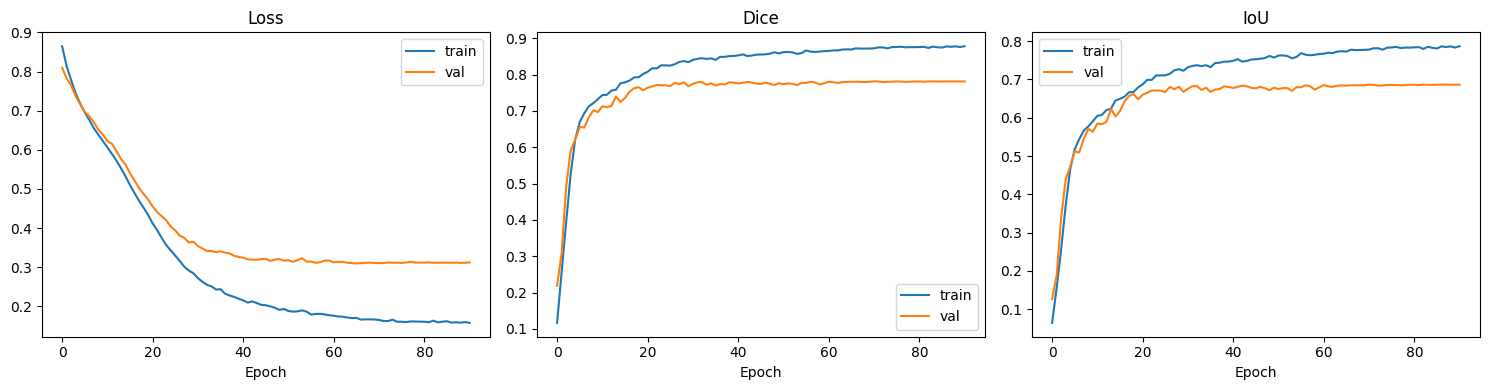

In [82]:
hist_df = pd.DataFrame(history)

history_csv = MODEL_DIR / f'{MODEL_NAME}_training_history.csv'
hist_df.to_csv(history_csv, index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df['train_loss'], label='train')
axes[0].plot(hist_df['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_df['train_dice'], label='train')
axes[1].plot(hist_df['val_dice'], label='val')
axes[1].set_title('Dice')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(hist_df['train_iou'], label='train')
axes[2].plot(hist_df['val_iou'], label='val')
axes[2].set_title('IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(CURVE_SAVE_PATH, dpi=200, bbox_inches='tight')
plt.show()

## 13. Threshold Validation

In [83]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])
_ = model.eval()

thresholds = np.arange(0.20, 0.81, 0.05)

rows = []

for threshold in thresholds:
    result = run_epoch(
        model,
        val_loader,
        optimizer=None,
        threshold=float(threshold)
    )

    rows.append({
        'threshold': round(float(threshold), 2),
        'dice': result['dice'],
        'iou': result['iou'],
        'precision': result['precision'],
        'recall': result['recall']
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(THRESHOLD_SWEEP_CSV, index=False)

display(threshold_df.sort_values(['iou', 'dice'], ascending=False))

,threshold,dice,iou,precision,recall
6,0.50,0.781197,0.686595,0.893156,0.768929
5,0.45,0.781252,0.686510,0.889536,0.772236
7,0.55,0.780922,0.686372,0.896458,0.765520
4,0.40,0.781188,0.686166,0.885551,0.775740
8,0.60,0.780460,0.685840,0.900026,0.761611
3,0.35,0.780856,0.685513,0.881125,0.779315
9,0.65,0.780005,0.685292,0.903696,0.757566
2,0.30,0.780583,0.684880,0.876337,0.783360
10,0.70,0.779380,0.684526,0.907409,0.753319
1,0.25,0.780242,0.684144,0.871202,0.787712


In [84]:
best_threshold = threshold_df.sort_values(
    ['iou', 'dice'],
    ascending=False
).iloc[0]

LESION_THRESHOLD = float(best_threshold['threshold'])

print(f'Selected lesion threshold: {LESION_THRESHOLD}')

Selected lesion threshold: 0.5


## 14. Evaluasi Test

In [85]:
def evaluate_per_image(model, dataset, threshold):
    loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    rows = []

    model.eval()

    with torch.no_grad():
        for image, mask, name in loader:
            image = image.to(DEVICE)
            mask = mask.to(DEVICE)

            logits = model(image)
            pred = (torch.sigmoid(logits) >= threshold).float()

            metrics = calculate_metrics(
                logits,
                mask,
                threshold=threshold
            )

            rows.append({
                'file': name[0],
                'dice': metrics['dice'],
                'iou': metrics['iou'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'gt_lesion_pct': float(mask.mean().item() * 100),
                'pred_lesion_pct': float(pred.mean().item() * 100)
            })

    return pd.DataFrame(rows)

In [86]:
test_df = evaluate_per_image(
    model,
    test_dataset,
    threshold=LESION_THRESHOLD
)

test_df.to_csv(TEST_EVAL_CSV, index=False)

test_summary = test_df[
    ['dice', 'iou', 'precision', 'recall', 'gt_lesion_pct', 'pred_lesion_pct']
].agg(['mean', 'std']).round(4)

display(test_summary)

,dice,iou,precision,recall,gt_lesion_pct,pred_lesion_pct
mean,0.8702,0.7786,0.8911,0.8648,4.0591,3.8693
std,0.0817,0.1172,0.0799,0.1215,3.0879,3.0380


## 15. Evaluasi Severity

In [87]:
def read_binary_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise FileNotFoundError(f'Mask tidak ditemukan: {path}')

    return (mask > 0).astype(np.uint8)


def severity_category(value):
    if value < 1:
        return 'Sangat Rendah'
    elif value <= 25:
        return 'Ringan'
    elif value <= 50:
        return 'Sedang'
    else:
        return 'Berat'

In [88]:
def evaluate_severity(model, dataset, threshold=LESION_THRESHOLD):
    loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    rows = []

    model.eval()

    with torch.no_grad():
        for image, lesion_gt, name in loader:
            image = image.to(DEVICE)

            logits = model(image)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            lesion_pred = (prob >= threshold).astype(np.uint8)

            lesion_gt = (lesion_gt[0, 0].cpu().numpy() > 0.5).astype(np.uint8)

            leaf_path = dataset.leaf_dir / f'{name[0]}_leaf.png'
            leaf_mask = read_binary_mask(leaf_path)

            leaf_area = int(leaf_mask.sum())
            gt_area = int(lesion_gt.sum())
            pred_area = int(lesion_pred.sum())

            if leaf_area > 0:
                gt_severity = gt_area / leaf_area * 100
                pred_severity = pred_area / leaf_area * 100
                error = abs(pred_severity - gt_severity)
            else:
                gt_severity = np.nan
                pred_severity = np.nan
                error = np.nan

            rows.append({
                'file': name[0],
                'leaf_area': leaf_area,
                'gt_lesion_area': gt_area,
                'pred_lesion_area': pred_area,
                'gt_severity': gt_severity,
                'pred_severity': pred_severity,
                'abs_error': error,
                'gt_category': severity_category(gt_severity) if not np.isnan(gt_severity) else None,
                'pred_category': severity_category(pred_severity) if not np.isnan(pred_severity) else None
            })

    return pd.DataFrame(rows)

In [89]:
severity_df = evaluate_severity(
    model,
    test_dataset,
    threshold=LESION_THRESHOLD
)

severity_df.to_csv(SEVERITY_EVAL_CSV, index=False)

severity_mae = severity_df['abs_error'].mean()
severity_rmse = np.sqrt((severity_df['abs_error'] ** 2).mean())
category_acc = (severity_df['gt_category'] == severity_df['pred_category']).mean()

severity_summary = pd.DataFrame({
    'metric': ['MAE Severity', 'RMSE Severity', 'Category Accuracy'],
    'value': [severity_mae, severity_rmse, category_acc]
}).round(4)

display(severity_summary)

,metric,value
0,MAE Severity,1.1050
1,RMSE Severity,1.7011
2,Category Accuracy,0.9855


## 16. Simpan Konfigurasi

In [90]:
config = {
    'model_name': MODEL_NAME,
    'architecture': ARCHITECTURE,
    'encoder': ENCODER_NAME,
    'encoder_weights': ENCODER_WEIGHTS,

    'img_size': IMG_SIZE,
    'preprocessing': 'predicted_leaf_mask_bgblack',
    'leaf_threshold': LEAF_THRESHOLD,
    'lesion_threshold': LESION_THRESHOLD,
    'masked_bg_value': MASKED_BG_VALUE,
    'leaf_pad_value': LEAF_PAD_VALUE,

    'leaf_model_path': str(LEAF_MODEL_PATH),
    'best_model_path': str(MODEL_SAVE_PATH),
    'last_model_path': str(LAST_MODEL_SAVE_PATH),

    'loss': {
        'bce_weight': BCE_WEIGHT,
        'dice_weight': DICE_WEIGHT,
        'jaccard_weight': JACCARD_WEIGHT
    },

    'training': {
        'optimizer': 'Adam',
        'lr': LR,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'scheduler_patience': SCHEDULER_PATIENCE,
        'best_epoch': int(best_epoch),
        'best_val_iou': float(best_iou)
    },

    'data_count': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset)
    },

    'outputs': {
        'threshold_sweep_csv': str(THRESHOLD_SWEEP_CSV),
        'test_eval_csv': str(TEST_EVAL_CSV),
        'severity_eval_csv': str(SEVERITY_EVAL_CSV),
        'training_curve': str(CURVE_SAVE_PATH)
    }
}

with open(CONFIG_SAVE_PATH, 'w') as f:
    json.dump(config, f, indent=4)

CONFIG_SAVE_PATH

PosixPath('/content/drive/MyDrive/SkripsiFinal/models/model_segmentasi_lesi_efficientnetb0/model_segmentasi_lesi_efficientnetb0_config.json')